# Iris Data Set: Load, Clean, and Visualize

**What is an iris?** It's a genus of flowering plant. This classic data set contains measurements of 150 individual iris flowers, drawn from 3 species: *setosa*, *versicolor*, and *virginica* (50 flowers each).

**What's being measured?** Each flower has two sets of "leaves": **sepals** (the outer, usually green, leaf-like parts that protect the bud before it blooms) and **petals** (the colorful inner parts most people think of as "the flower"). For each flower we have four measurements -- sepal length, sepal width, petal length, and petal width -- all recorded in **centimeters (cm)**.

*(Note: the original assignment said "septal length" -- that's a typo for "sepal", which is the real botanical term and what the data set actually calls this measurement, so that's what's used throughout.)*

This tiny, clean data set is a classic "hello world" for machine learning because the three species are fairly easy to separate using just these four numbers.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# scikit-learn ships this data set built in (no download needed), as a
# collection of arrays. We pull it out and reassemble it into a pandas
# DataFrame, which is just a table -- one row per flower, one column per
# measurement -- because tables are much easier to filter and plot.
iris_raw = load_iris()

iris_df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)

# The species is stored separately as numbers (0, 1, 2). We map those
# numbers back to their real species names so the plot legend and any
# printed output are human-readable instead of showing "0", "1", "2".
iris_df["species"] = pd.Categorical.from_codes(
    iris_raw.target, iris_raw.target_names
)

# Rename the columns to simpler names (dropping the "(cm)" and spaces)
# so they're easier to type/reference later in the script.
iris_df = iris_df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
})

print(f"Loaded {len(iris_df)} iris flowers.")
iris_df.head()


Loaded 150 iris flowers.
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


## Cleaning step: drop rows where sepal length > 5cm

In plain terms: we're throwing away every flower whose outer protective "leaf" (the sepal) is longer than 5 centimeters, keeping only the smaller-sepaled flowers. This is a simple example of data filtering -- in a real project you might filter out outliers, bad sensor readings, or (as here) just restrict your analysis to a subset you care about.

**Heads up:** this filter happens to remove almost all of the *virginica* species, since virginica flowers tend to have longer sepals than the other two species -- so don't be surprised that the plot below ends up dominated by setosa and versicolor.


In [2]:
before_count = len(iris_df)
iris_df = iris_df[iris_df["sepal_length"] <= 5]
after_count = len(iris_df)

print(f"Dropped {before_count - after_count} rows with sepal_length > 5cm.")
print(f"{after_count} rows remain.")


Dropped 118 rows with sepal_length > 5cm.\n32 rows remain.\n

## Visualize: petal length vs. sepal length, colored by species

A scatter plot puts one dot per flower: its x-position is the sepal length, its y-position is the petal length. Coloring each dot by species lets us visually check whether the species naturally cluster into separate groups based on these two measurements -- which is exactly the kind of pattern a machine learning classifier would try to learn.


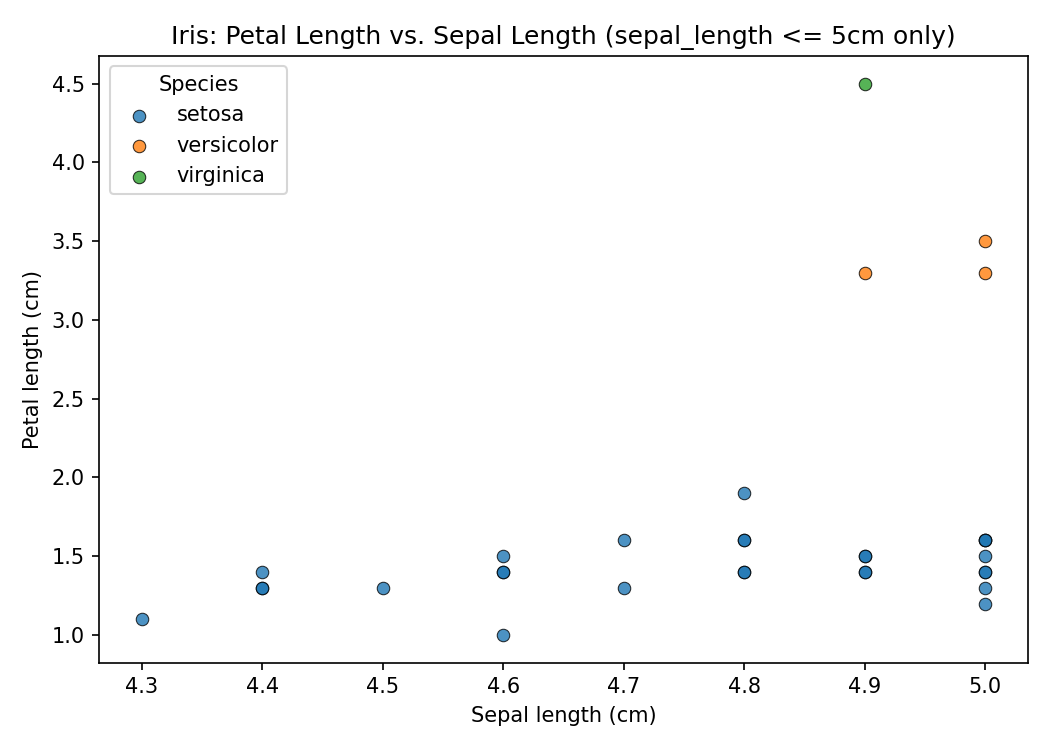

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

species_colors = {"setosa": "tab:blue", "versicolor": "tab:orange", "virginica": "tab:green"}

for species_name, group in iris_df.groupby("species", observed=True):
    ax.scatter(
        group["sepal_length"],
        group["petal_length"],
        label=species_name,
        color=species_colors.get(species_name, "gray"),
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_xlabel("Sepal length (cm)")
ax.set_ylabel("Petal length (cm)")
ax.set_title("Iris: Petal Length vs. Sepal Length (sepal_length <= 5cm only)")
ax.legend(title="Species")
fig.tight_layout()
plt.show()
